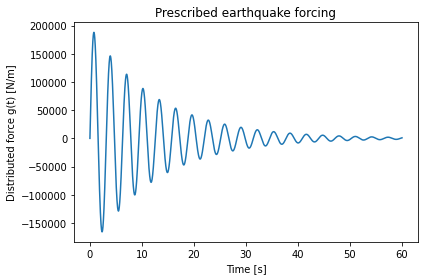

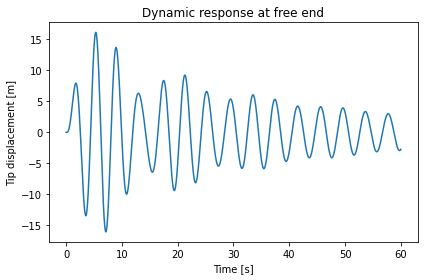

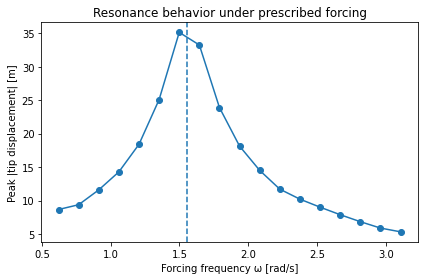

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) BUILD SEMI-DISCRETE BEAM MATRICES (M, C, K)
# ============================================================

def build_beam_matrices(E, I, rho, A, L, n, rayleigh=None, c_lumped=None):
    """
    Constructs the mass (M), damping (C), and stiffness (K) matrices
    for the Euler–Bernoulli beam after spatial discretization using
    the 5-point fourth-derivative stencil.

    Boundary conditions:
      - clamped at x = 0
      - free (zero moment and shear) at x = L

    Unknowns correspond to interior nodes j = 3,...,n-1
    """

    dx = L / n                     # Spatial step size Δx
    N = n + 1                      # Total number of grid points (including boundaries)
    m_int = N - 4                  # Number of interior unknowns (u_3 ... u_{n-1})

    # --------------------------------------------------------
    # Transformation matrix T
    # Maps interior DOFs → full nodal vector
    # Used to enforce boundary conditions algebraically
    # --------------------------------------------------------
    T = np.zeros((N, m_int))

    # Left boundary: u(0) = 0 → u1 = 0 (already satisfied)

    # Zero slope at x = 0: u_x(0) = 0
    # From finite difference: (-3u1 + 4u2 - u3)/(2Δx) = 0
    # With u1 = 0 → u2 = u3 / 4
    T[1, 0] = 1.0 / 4.0

    # Interior nodes map directly
    for i in range(m_int):
        full_idx = 2 + i           # full node index corresponding to u_{i+3}
        T[full_idx, i] = 1.0

    # Free-end boundary conditions at x = L:
    #   u_xx(L) = 0   (zero bending moment)
    #   u_xxx(L) = 0  (zero shear force)
    #
    # These give algebraic relations for the last two nodes
    T[N-2, m_int-1] = 2.0
    T[N-2, m_int-2] = -1.0
    T[N-1, m_int-1] = 3.0
    T[N-1, m_int-2] = -2.0

    # --------------------------------------------------------
    # Fourth-derivative operator S (5-point stencil)
    # --------------------------------------------------------
    S = np.zeros((m_int, N))

    for i in range(m_int):
        j = 2 + i                  # Full index of interior node
        S[i, j-2] =  1.0
        S[i, j-1] = -4.0
        S[i, j]   =  6.0
        S[i, j+1] = -4.0
        S[i, j+2] =  1.0

    S /= dx**4                     # Divide by Δx⁴

    # --------------------------------------------------------
    # Stiffness matrix K = EI * (fourth derivative operator)
    # --------------------------------------------------------
    K = E * I * (S @ T)

    # --------------------------------------------------------
    # Mass matrix M (lumped, diagonal)
    # m = ρA is mass per unit length
    # --------------------------------------------------------
    m_line = rho * A
    M = m_line * np.eye(m_int)

    # --------------------------------------------------------
    # Damping matrix C
    # Either Rayleigh damping or simple lumped damping
    # --------------------------------------------------------
    if rayleigh is not None:
        alpha_R, beta_R = rayleigh
        C = alpha_R * K + beta_R * M
    elif c_lumped is not None:
        C = c_lumped * np.eye(m_int)
    else:
        C = np.zeros_like(K)

    return M, C, K, dx


# ============================================================
# 2) NATURAL FREQUENCIES
# ============================================================

def natural_frequencies(M, K, nmodes=6):
    """
    Solves the generalized eigenvalue problem:
        K φ = ω² M φ

    Returns the first nmodes natural frequencies ω_k
    """

    MinvK = np.linalg.solve(M, K)      # Forms M⁻¹K
    eigvals, _ = np.linalg.eig(MinvK)  # Eigenvalues = ω²
    eigvals = np.real(eigvals)
    eigvals = eigvals[eigvals > 0]
    eigvals.sort()

    return np.sqrt(eigvals[:nmodes])   # ω = sqrt(λ)


# ============================================================
# 3) PRESCRIBED FORCING FUNCTION g(t)
# ============================================================

def forcing_time_history(t, F0, omega, alpha):
    """
    Distributed force per unit length (N/m):
        g(t) = F0 * exp(-α t) * sin(ω t)
    """
    return F0 * np.exp(-alpha * t) * np.sin(omega * t)


# ============================================================
# 4) NEWMARK–β TIME INTEGRATION
# ============================================================

def newmark_beta(M, C, K, g_fun, t, u0=None, v0=None, beta=1/4, gamma=1/2):
    """
    Solves:
        M ü + C u̇ + K u = g(t)

    using the Newmark–β method (implicit, second-order accurate).
    """

    dt = t[1] - t[0]                  # Time step size
    nsteps = len(t)                   # Number of time steps
    ndof = M.shape[0]                 # Number of DOFs

    # Allocate solution arrays
    u = np.zeros((nsteps, ndof))      # Displacement
    v = np.zeros((nsteps, ndof))      # Velocity
    a = np.zeros((nsteps, ndof))      # Acceleration

    # Initial conditions
    if u0 is not None:
        u[0] = u0
    if v0 is not None:
        v[0] = v0

    # Initial acceleration from equilibrium
    a[0] = np.linalg.solve(M, g_fun(t[0]) - C @ v[0] - K @ u[0])

    # Effective stiffness matrix
    K_eff = K + (gamma/(beta*dt))*C + (1/(beta*dt**2))*M
    K_eff_inv = np.linalg.inv(K_eff)

    # Time stepping loop
    for n in range(nsteps - 1):

        # Predictor step
        u_pred = u[n] + dt*v[n] + dt**2*(0.5 - beta)*a[n]
        v_pred = v[n] + dt*(1 - gamma)*a[n]

        # Effective right-hand side
        rhs = (
            g_fun(t[n+1])
            + M @ ((1/(beta*dt**2))*u_pred)
            + C @ ((gamma/(beta*dt))*u_pred - v_pred)
        )

        # Solve for displacement at next step
        u[n+1] = K_eff_inv @ rhs

        # Recover acceleration and velocity
        a[n+1] = (1/(beta*dt**2))*(u[n+1] - u_pred)
        v[n+1] = v_pred + dt*gamma*a[n+1]

    return u, v, a


# ============================================================
# 5) RUN STUDIES + GENERATE PLOTS
# ============================================================

def run_studies_and_plot():

    # -------------------------
    # Structural parameters
    # -------------------------
    E   = 25e9        # Young's modulus [Pa]
    rho = 2500.0      # Density [kg/m^3]
    L   = 120.0       # Beam length [m]
    n   = 80          # Number of spatial subdivisions

    A0 = 8.0          # Reference cross-sectional area [m^2]
    I0 = 30.0         # Reference second moment of area [m^4]

    alpha_R = 0.02    # Rayleigh damping coefficient
    beta_R  = 0.0002

    # -------------------------
    # Forcing parameters
    # -------------------------
    F0    = 2.0e5     # Force amplitude [N/m]
    omega = 2.0       # Forcing frequency [rad/s]
    alpha = 0.08      # Decay rate [1/s]

    # -------------------------
    # Time grid
    # -------------------------
    T_end = 60.0
    dt = 0.01
    t = np.arange(0, T_end + dt, dt)

    # Helper: forcing vector
    def make_gvec(ndof):
        return lambda tk: forcing_time_history(tk, F0, omega, alpha) * np.ones(ndof)

    # -------------------------
    # Build system
    # -------------------------
    M, C, K, dx = build_beam_matrices(E, I0, rho, A0, L, n, rayleigh=(alpha_R, beta_R))
    omegas = natural_frequencies(M, K)
    omega1 = omegas[0]

    # -------------------------
    # Solve time response
    # -------------------------
    u, v, a = newmark_beta(M, C, K, make_gvec(M.shape[0]), t)

    # -------------------------
    # PLOTS
    # -------------------------

    # Earthquake forcing
    plt.figure()
    plt.plot(t, forcing_time_history(t, F0, omega, alpha))
    plt.xlabel("Time [s]")
    plt.ylabel("Distributed force g(t) [N/m]")
    plt.title("Prescribed earthquake forcing")
    plt.tight_layout()

    # Tip displacement response
    plt.figure()
    plt.plot(t, u[:, -1])
    plt.xlabel("Time [s]")
    plt.ylabel("Tip displacement [m]")
    plt.title("Dynamic response at free end")
    plt.tight_layout()

    # Frequency response (resonance)
    omega_sweep = np.linspace(0.4*omega1, 2.0*omega1, 18)
    peaks = []

    for w in omega_sweep:
        g_fun = lambda tk: forcing_time_history(tk, F0, w, alpha) * np.ones(M.shape[0])
        u_tmp, _, _ = newmark_beta(M, C, K, g_fun, t)
        peaks.append(np.max(np.abs(u_tmp[:, -1])))

    plt.figure()
    plt.plot(omega_sweep, peaks, marker="o")
    plt.axvline(omega1, linestyle="--")
    plt.xlabel("Forcing frequency ω [rad/s]")
    plt.ylabel("Peak |tip displacement| [m]")
    plt.title("Resonance behavior under prescribed forcing")
    plt.tight_layout()

    plt.show()


# ============================================================
# EXECUTE
# ============================================================
run_studies_and_plot()
